# Car Price Prediction using Machine Learning

## Business Objective

The objective of this project is to predict the selling price of used cars based on their features such as brand, vehicle age, fuel type, engine capacity, mileage, transmission type, and other characteristics.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("cardekho_dataset.csv")

In [3]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5.0,120000.0
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5.0,550000.0
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5.0,215000.0
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5.0,226000.0
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5.0,570000.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11905 entries, 0 to 11904
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         11905 non-null  int64  
 1   car_name           11905 non-null  object 
 2   brand              11905 non-null  object 
 3   model              11905 non-null  object 
 4   vehicle_age        11905 non-null  int64  
 5   km_driven          11905 non-null  int64  
 6   seller_type        11905 non-null  object 
 7   fuel_type          11905 non-null  object 
 8   transmission_type  11905 non-null  object 
 9   mileage            11905 non-null  float64
 10  engine             11905 non-null  int64  
 11  max_power          11905 non-null  float64
 12  seats              11904 non-null  float64
 13  selling_price      11904 non-null  float64
dtypes: float64(4), int64(4), object(6)
memory usage: 1.3+ MB


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0


## Dataset Overview

The dataset contains information about used cars listed on CarDekho, including vehicle specifications and their selling prices.

## Target Variable

The target variable is **selling_price**.

## Features

### Numerical Features
- vehicle_age
- km_driven
- mileage
- engine
- max_power
- seats

### Categorical Features
- car_name
- brand
- model
- seller_type
- fuel_type
- transmission_type

In [6]:
df = df.drop("Unnamed: 0", axis=1)

In [7]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5.0,120000.0
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5.0,550000.0
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5.0,215000.0
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5.0,226000.0
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5.0,570000.0


In [8]:
df = df.dropna()

In [9]:
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0
engine,0


## Data Preprocessing

- Removed the unnecessary "Unnamed: 0" column.
- Removed rows containing missing values.
- Applied One-Hot Encoding to categorical features.
- Split the dataset into training and testing sets.

In [10]:
df.shape

(11904, 13)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [12]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,11904.000000,1.190400e+04,11904.000000,11904.000000,11904.000000,11904.000000,1.190400e+04
mean,6.024782,5.550527e+04,19.732146,1484.005712,100.122740,5.332829,7.632983e+05
std,3.011135,4.341778e+04,4.180011,522.304527,43.006178,0.815570,9.163168e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.777500e+05
50%,6.000000,5.000000e+04,19.700000,1248.000000,88.500000,5.000000,5.500000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.000000e+05
max,29.000000,1.325000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


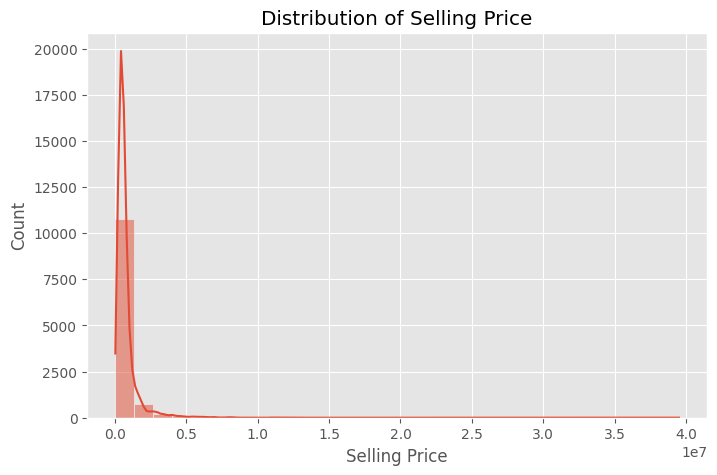

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["selling_price"], bins=30, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.show()

### Observation

The selling price distribution is right-skewed. Most used cars are concentrated in the lower price range, while only a few cars have very high selling prices.

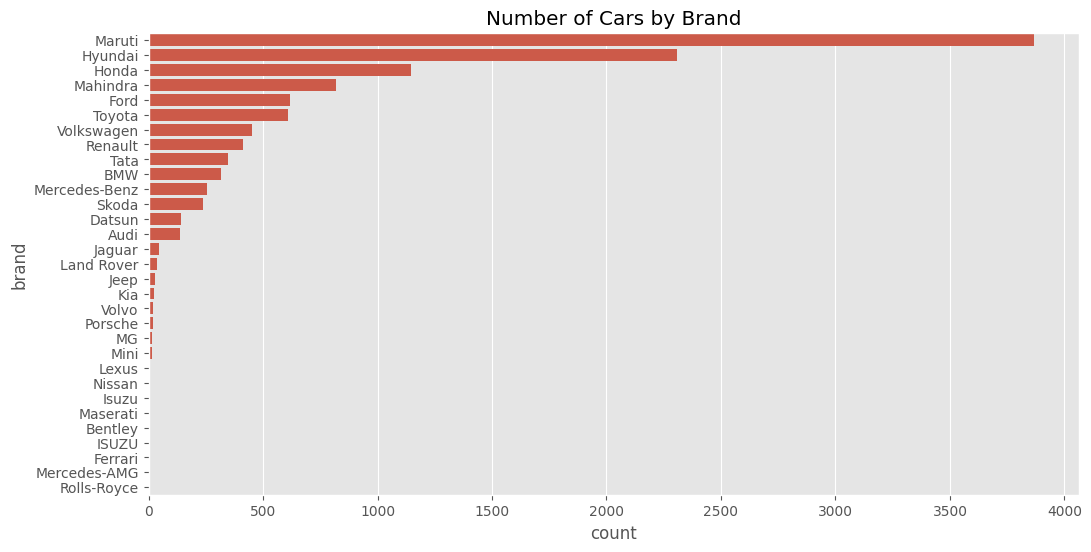

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(y="brand", data=df, order=df["brand"].value_counts().index)
plt.title("Number of Cars by Brand")
plt.show()

### Observation

Maruti and Hyundai have the highest number of cars in the dataset, indicating that these brands are the most common among the listed used cars.

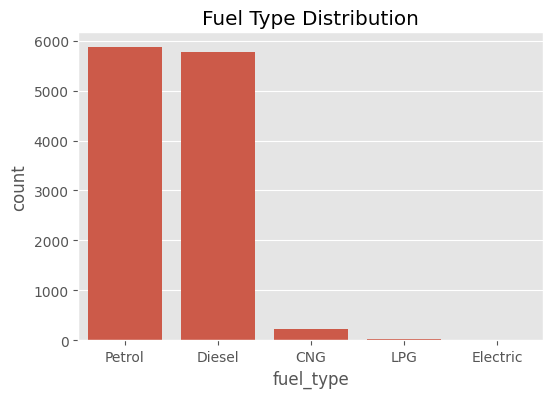

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="fuel_type", data=df)
plt.title("Fuel Type Distribution")
plt.show()

### Observation

Petrol and Diesel are the most common fuel types in the dataset, while Electric and LPG vehicles are comparatively fewer.

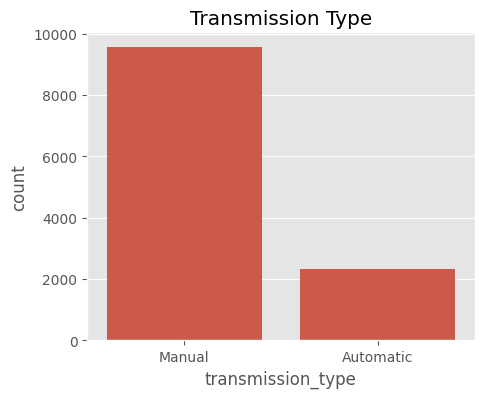

In [16]:
plt.figure(figsize=(5,4))
sns.countplot(x="transmission_type", data=df)
plt.title("Transmission Type")
plt.show()

### Observation

Most cars in the dataset use manual transmission, whereas automatic transmission vehicles are fewer.

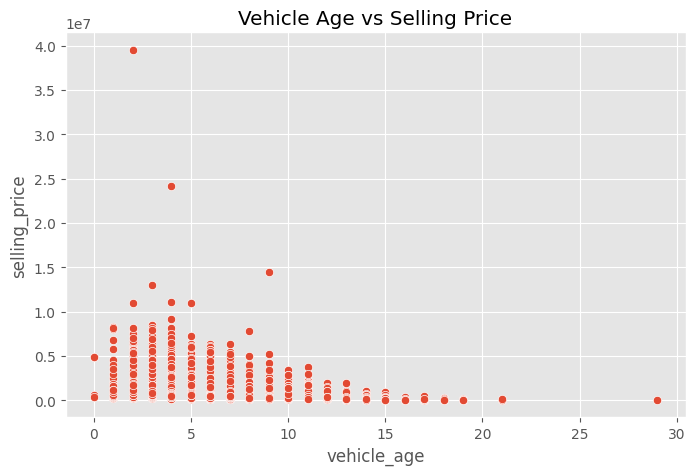

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="vehicle_age", y="selling_price", data=df)
plt.title("Vehicle Age vs Selling Price")
plt.show()

### Observation

There is a negative relationship between vehicle age and selling price. As the age of a vehicle increases, its selling price generally decreases.

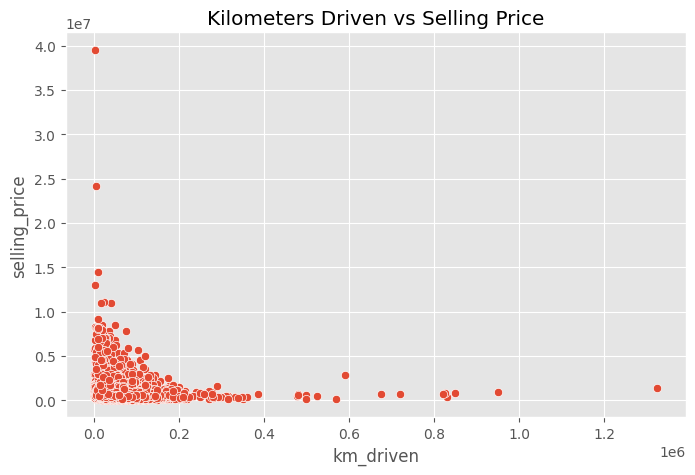

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="km_driven", y="selling_price", data=df)
plt.title("Kilometers Driven vs Selling Price")
plt.show()

### Observation

Cars with higher kilometers driven generally tend to have lower selling prices, although there are a few exceptions.

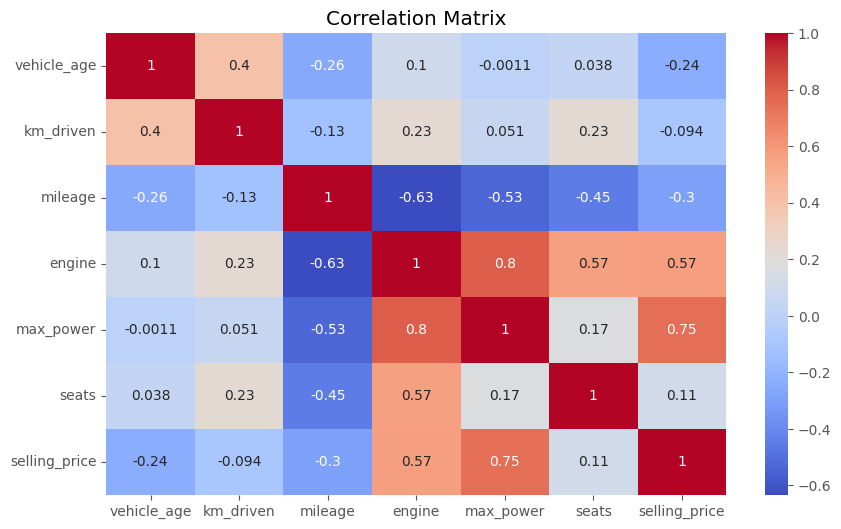

In [19]:
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

### Observation

The correlation heatmap shows that max_power and engine have the strongest positive correlation with selling price, while vehicle age and mileage have negative correlations. This indicates that engine performance has a significant influence on the selling price.

In [20]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

In [21]:
X.select_dtypes(include="object").columns

Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
       'transmission_type'],
      dtype='object')

In [22]:
X = pd.get_dummies(X, drop_first=True)

In [23]:
X.head()

,vehicle_age,km_driven,mileage,engine,max_power,seats,car_name_Audi A6,car_name_Audi A8,car_name_Audi Q7,car_name_BMW 3,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5.0,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,5.0,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,5.0,False,False,False,False,...,False,True,False,True,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,5.0,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,5.0,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
print(X_train.shape)
print(X_test.shape)

(9523, 279)
(2381, 279)


## Linear Regression

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
lr = LinearRegression()

In [28]:
model = LinearRegression()

In [29]:
lr.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred_lr = lr.predict(X_test)

In [31]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [32]:
mae = mean_absolute_error(y_test, y_pred_lr)

mse = mean_squared_error(y_test, y_pred_lr)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_lr)

In [33]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 176056.2673245808
MSE : 155890772742.19434
RMSE: 394830.05552033946
R2 Score: 0.792939329931794


## Decision Tree Regressor

In [34]:
from sklearn.tree import DecisionTreeRegressor

In [35]:
dt = DecisionTreeRegressor(random_state=42)

In [36]:
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [37]:
y_pred_dt = dt.predict(X_test)

In [38]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

MAE : 122317.67114657706
MSE : 93946004328.97592
RMSE: 306506.12445590046
R2 Score: 0.8752169723428204


## Random Forest Regressor

In [39]:
from sklearn.ensemble import RandomForestRegressor

In [40]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [41]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [42]:
y_pred_rf = rf.predict(X_test)

In [43]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE : 96925.1992275306
MSE : 53207327668.75943
RMSE: 230667.13608305677
R2 Score: 0.9293277932629687


In [44]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        mae_dt,
        mae_rf
    ],
    "MSE": [
        mse,
        mse_dt,
        mse_rf
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf
    ],
    "R2 Score": [
        r2,
        r2_dt,
        r2_rf
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,176056.267325,1.558908e+11,394830.055520,0.792939
1,Decision Tree,122317.671147,9.394600e+10,306506.124456,0.875217
2,Random Forest,96925.199228,5.320733e+10,230667.136083,0.929328


## Performance Comparison

Random Forest achieved the best performance with the highest R² score and the lowest prediction error.

## Conclusion

Among the three regression models, Random Forest Regressor performed the best with an R² score of 0.9293. It produced the lowest MAE, MSE, and RMSE, making it the most accurate model for predicting used car selling prices.